In [1]:

import numpy as np
import pandas as pd
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
def load_file(filepath):
    dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
    return dataframe.values


In [4]:
# load a list of files and return as a 3d numpy array
def load_group(filenames, prefix=''):
    loaded = list()
    for name in filenames:
        data = load_file(prefix + name)
        loaded.append(data)
    # stack group so that features are the 3rd dimension
    loaded = np.dstack(loaded)
    return loaded

In [5]:
# load a dataset group, such as train or test
def load_dataset_group(group, prefix=''):
    filepath = prefix + group + '/Inertial Signals/'
    # load all 9 files as a single array
    filenames = list()
    # total acceleration
    filenames += ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt']
    # body acceleration
    filenames += ['body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt']
    # body gyroscope
    filenames += ['body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
    # load input data
    X = load_group(filenames, filepath)
    # load class output
    y = load_file(prefix + group + '/y_'+group+'.txt')
    return X, y

In [6]:
# load the dataset, returns train and test X and y elements
def load_dataset(prefix=''):
    # load all train
    trainX, trainy = load_dataset_group('train', prefix + '/content/drive/MyDrive/Colab Notebooks/UCI HAR Dataset/UCI HAR Dataset/')
    # load all test
    testX, testy = load_dataset_group('test', prefix + '/content/drive/MyDrive/Colab Notebooks/UCI HAR Dataset/UCI HAR Dataset/')

    #zero-offset class values
    trainy = trainy - 1
    testy = testy - 1
    #one hot encode y
    trainy_one_hot = to_categorical(trainy)
    testy_one_hot = to_categorical(testy)
    print(trainX.shape, trainy.shape, trainy_one_hot.shape, testX.shape, testy.shape, testy_one_hot.shape)
    return trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot


In [7]:
trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot = load_dataset()

/tmp/ipython-input-473047976.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-473047976.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-473047976.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-473047976.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp

(7352, 128, 9) (7352, 1) (7352, 6) (2947, 128, 9) (2947, 1) (2947, 6)


In [8]:
from sklearn.model_selection import train_test_split

X_train,X_val,y_train_one_hot,y_val_one_hot,y_train,y_val=train_test_split(trainX, trainy_one_hot, trainy,test_size=0.2,random_state=100)


In [9]:
X_train.shape,X_val.shape,y_train_one_hot.shape,y_val_one_hot.shape,y_train.shape,y_val.shape

((5881, 128, 9), (1471, 128, 9), (5881, 6), (1471, 6), (5881, 1), (1471, 1))

In [10]:
n_timesteps, n_features, n_outputs = X_train.shape[1], X_train.shape[2], y_train_one_hot.shape[1]


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, GlobalAveragePooling1D, GlobalMaxPooling1D,
    Dense, Dropout, Concatenate, Multiply, Reshape, Add,
    BatchNormalization, Activation, Lambda
)
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K


In [12]:
def channel_attention(input_tensor, channels, reduction=16):
    """Channel Attention Module"""

    # Average pooling
    avg_pool = GlobalAveragePooling1D()(input_tensor)
    avg_pool = Reshape((1, channels))(avg_pool)

    # Max pooling
    max_pool = GlobalMaxPooling1D()(input_tensor)
    max_pool = Reshape((1, channels))(max_pool)

    # Shared MLP
    dense1 = Dense(channels // reduction, activation='relu')
    dense2 = Dense(channels, activation='sigmoid')

    avg_out = dense2(dense1(avg_pool))
    max_out = dense2(dense1(max_pool))

    # Combine
    attention = Add()([avg_out, max_out])

    # Apply attention
    output = Multiply()([input_tensor, attention])

    return output


In [13]:
def spatial_attention(input_tensor):
    """Spatial Attention Module for 1D signals"""

    # Channel-wise statistics
    avg_pool = Lambda(lambda x: K.mean(x, axis=-1, keepdims=True))(input_tensor)
    max_pool = Lambda(lambda x: K.max(x, axis=-1, keepdims=True))(input_tensor)

    # Concatenate
    concat = Concatenate(axis=-1)([avg_pool, max_pool])

    # Convolution
    attention = Conv1D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)

    # Apply attention
    output = Multiply()([input_tensor, attention])

    return output

In [14]:
def cbam_block(input_tensor, channels, reduction=16):
    """CBAM: Convolutional Block Attention Module"""

    # Channel attention
    x = channel_attention(input_tensor, channels, reduction)

    # Spatial attention
    x = spatial_attention(x)

    return x

In [15]:
def conv_block_cbam(input_tensor, filters, kernel_size=3, strides=1):
    """Convolutional Block with CBAM"""

    x = Conv1D(filters, kernel_size=kernel_size, strides=strides, padding='same')(input_tensor)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = cbam_block(x, filters)

    return x

In [16]:
def create_cbam_model(n_timesteps=128, n_features=9, n_outputs=6):
    """
    CBAM 모델 생성

    Args:
        n_timesteps: 시퀀스 길이 (기본: 128)
        n_features: 입력 특징 수 (기본: 9)
        n_outputs: 출력 클래스 수 (기본: 6)

    Returns:
        Keras Model
    """

    # Input layer
    inputs = Input(shape=(n_timesteps, n_features))

    # Initial convolution
    x = Conv1D(64, kernel_size=7, strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(pool_size=3, strides=2, padding='same')(x)

    # Convolutional blocks with CBAM
    x = conv_block_cbam(x, 128, kernel_size=3, strides=1)
    x = MaxPooling1D(pool_size=2, strides=2)(x)

    x = conv_block_cbam(x, 256, kernel_size=3, strides=1)
    x = MaxPooling1D(pool_size=2, strides=2)(x)

    x = conv_block_cbam(x, 512, kernel_size=3, strides=1)
    x = MaxPooling1D(pool_size=2, strides=2)(x)

    x = conv_block_cbam(x, 512, kernel_size=3, strides=1)

    # Global Average Pooling
    x = GlobalAveragePooling1D()(x)

    # Fully connected layers
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)

    # Output layer
    outputs = Dense(n_outputs, activation='softmax')(x)

    # Create model
    model = Model(inputs=inputs, outputs=outputs, name='CBAM_HAR')

    return model


In [17]:
model = create_cbam_model(n_timesteps=128, n_features=9, n_outputs=6)


In [18]:
model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
)
# 모델 구조 확인
model.summary()

Model: "CBAM_HAR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 64, 64)    │      4,096 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 32, 64)    │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 32, 128)   │     24,704 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ activation_1[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ activation_1[0][… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 128)    │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 128)    │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 8)      │      1,032 │ reshape[0][0],    │
│                     │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 128)    │      1,152 │ dense[0][0],      │
│                     │                   │            │ dense[1][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 128)    │          0 │ dense_1[0][0],    │
│                     │                   │            │ dense_1[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 32, 128)   │          0 │ activation_1[0][… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 32, 1)     │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 32, 1)     │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 2)     │          0 │ lambda[0][0],   

 Total params: 1,524,122 (5.81 MB)

 Trainable params: 1,521,178 (5.80 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [19]:
history = model.fit(X_train, y_train_one_hot,
                    epochs=20,
                    batch_size=32,
                    validation_data=(X_val, y_val_one_hot),
                    verbose=1)

Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 32s 79ms/step - accuracy: 0.8025 - loss: 0.5198 - val_accuracy: 0.3916 - val_loss: 1.8507
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9323 - loss: 0.1744 - val_accuracy: 0.9245 - val_loss: 0.1564
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9370 - loss: 0.1685 - val_accuracy: 0.9415 - val_loss: 0.1367
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9404 - loss: 0.1443 - val_accuracy: 0.9545 - val_loss: 0.1117
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9529 - loss: 0.1333 - val_accuracy: 0.9490 - val_loss: 0.1163
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9484 - loss: 0.1362 - val_accuracy: 0.9429 - val_loss: 0.1286
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9460 - loss: 0.1398 - val_accuracy: 0.9409 - val_loss: 0.1197
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9441 - loss: 0.1383 - val_accuracy: 

In [20]:
test_loss, test_accuracy = model.evaluate(testX, testy_one_hot, verbose=0)

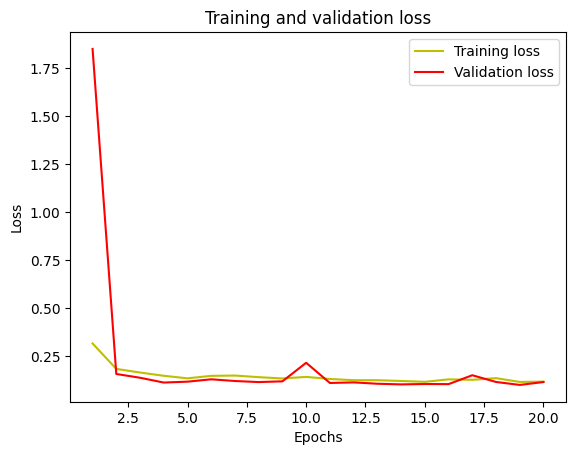

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

loss =history.history['loss']
val_loss =history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

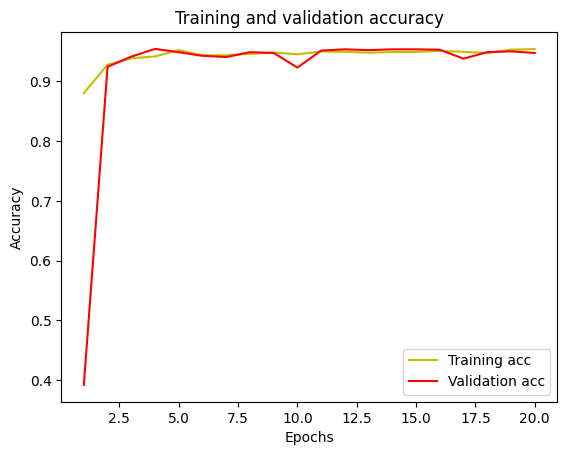

In [22]:


acc =history.history['accuracy']
val_acc =history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [23]:

from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
pred=model.predict(testX)
pred=np.argmax(pred, axis=-1)
cm=confusion_matrix(testy,pred)
print(cm)
print(accuracy_score(testy,pred))
print(classification_report(testy,pred))


93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step
[[496   0   0   0   0   0]
 [ 12 458   1   0   0   0]
 [ 20   1 399   0   0   0]
 [  0   0   0 356 128   7]
 [  1   0   0  44 487   0]
 [  0   0   0   0   0 537]]
0.9273837801153716
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       496
           1       1.00      0.97      0.98       471
           2       1.00      0.95      0.97       420
           3       0.89      0.73      0.80       491
           4       0.79      0.92      0.85       532
           5       0.99      1.00      0.99       537

    accuracy                           0.93      2947
   macro avg       0.93      0.93      0.93      2947
weighted avg       0.93      0.93      0.93      2947



<Axes: >

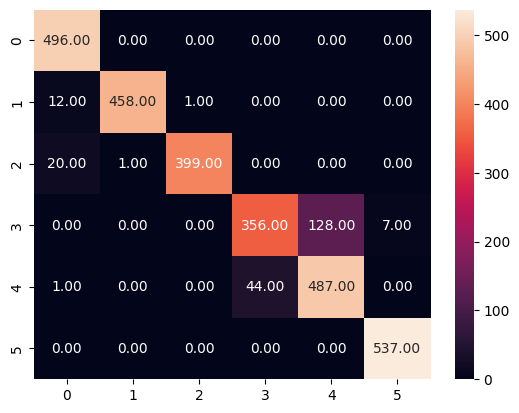

In [24]:
sns.heatmap(cm, annot=True, fmt = '.2f')